In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, roc_curve, precision_recall_curve)

try:
    from xgboost import XGBClassifier
    print("XGBoost loaded!")
except ImportError:
    print("Installing XGBoost...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost', '--break-system-packages'])
    from xgboost import XGBClassifier
    print("XGBoost installed and loaded!")

print("All libraries loaded!")

XGBoost loaded!
All libraries loaded!


In [3]:
np.random.seed(42)
n = 3000

# Borrower features
age = np.random.randint(22, 65, n)
income = np.random.lognormal(mean=10.8, sigma=0.5, size=n).clip(20000, 300000).astype(int)
loan_amount = (income * np.random.uniform(0.5, 4.0, n)).clip(5000, 500000).astype(int)
credit_score = np.random.normal(680, 80, n).clip(300, 850).astype(int)
employment_years = np.random.exponential(5, n).clip(0, 35).astype(int)
debt_to_income = (np.random.beta(2, 5, n) * 60).clip(5, 55).round(1)
num_credit_lines = np.random.poisson(5, n).clip(0, 20)
loan_term = np.random.choice([12, 24, 36, 48, 60], n, p=[0.05, 0.15, 0.35, 0.25, 0.20])
home_ownership = np.random.choice(['Own', 'Mortgage', 'Rent'], n, p=[0.20, 0.45, 0.35])
loan_purpose = np.random.choice(['Debt Consolidation', 'Home Improvement', 'Business',
                                  'Education', 'Medical', 'Other'], n,
                                 p=[0.35, 0.20, 0.15, 0.10, 0.10, 0.10])

# Generate default probability based on features
default_prob = (
    0.05 +
    0.15 * (credit_score < 620).astype(float) +
    0.10 * (debt_to_income > 35).astype(float) +
    0.08 * (employment_years < 2).astype(float) +
    0.05 * (loan_amount / income > 3).astype(float) +
    0.03 * (num_credit_lines > 10).astype(float) +
    np.random.normal(0, 0.05, n)
).clip(0.02, 0.80)

default = (np.random.random(n) < default_prob).astype(int)

df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Loan_Amount': loan_amount,
    'Credit_Score': credit_score,
    'Employment_Years': employment_years,
    'Debt_to_Income': debt_to_income,
    'Num_Credit_Lines': num_credit_lines,
    'Loan_Term': loan_term,
    'Home_Ownership': home_ownership,
    'Loan_Purpose': loan_purpose,
    'Default': default
})

print(f"Dataset: {len(df)} loans")
print(f"\nDefault rate: {df['Default'].mean():.1%}")
print(f"  Defaulted: {df['Default'].sum()} ({df['Default'].mean():.1%})")
print(f"  Repaid:    {(df['Default']==0).sum()} ({(df['Default']==0).mean():.1%})")
print(f"\nSample data:")
print(df.head())


Dataset: 3000 loans

Default rate: 12.8%
  Defaulted: 384 (12.8%)
  Repaid:    2616 (87.2%)

Sample data:
   Age  Income  Loan_Amount  Credit_Score  Employment_Years  Debt_to_Income  \
0   60   37837        46789           720                 8             5.0   
1   50   55299       161115           743                 5            21.2   
2   36   47197       168520           631                 0            10.5   
3   64   75944       115151           682                 2            10.3   
4   29   40364        31767           693                 2            18.8   

   Num_Credit_Lines  Loan_Term Home_Ownership        Loan_Purpose  Default  
0                 2         48            Own            Business        0  
1                 3         60       Mortgage  Debt Consolidation        0  
2                 6         24       Mortgage           Education        0  
3                 5         24           Rent    Home Improvement        0  
4                 6         36    

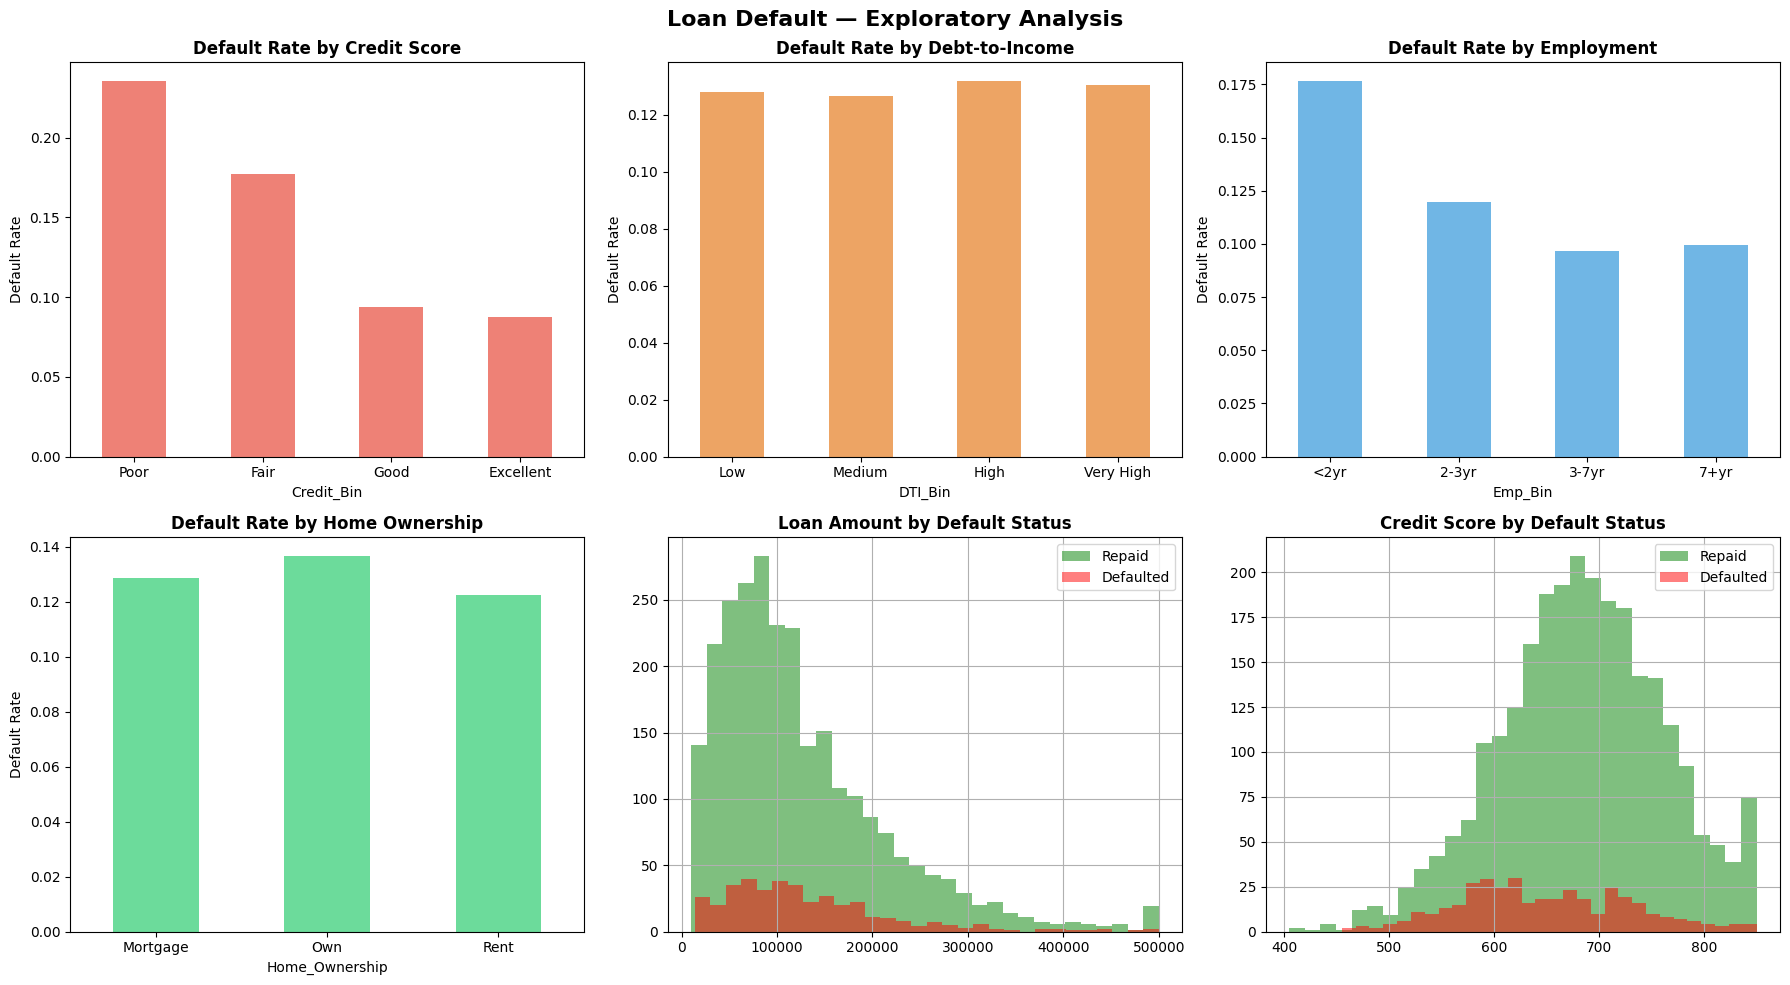

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Default rate by credit score bins
df['Credit_Bin'] = pd.cut(df['Credit_Score'], bins=[300,580,650,720,850],
                           labels=['Poor','Fair','Good','Excellent'])
df.groupby('Credit_Bin')['Default'].mean().plot(kind='bar', ax=axes[0,0], color='#e74c3c', alpha=0.7)
axes[0,0].set_title('Default Rate by Credit Score', fontweight='bold')
axes[0,0].set_ylabel('Default Rate')
axes[0,0].tick_params(axis='x', rotation=0)

# Default rate by DTI bins
df['DTI_Bin'] = pd.cut(df['Debt_to_Income'], bins=[0,20,30,40,60],
                        labels=['Low','Medium','High','Very High'])
df.groupby('DTI_Bin')['Default'].mean().plot(kind='bar', ax=axes[0,1], color='#e67e22', alpha=0.7)
axes[0,1].set_title('Default Rate by Debt-to-Income', fontweight='bold')
axes[0,1].set_ylabel('Default Rate')
axes[0,1].tick_params(axis='x', rotation=0)

# Default rate by employment years
df['Emp_Bin'] = pd.cut(df['Employment_Years'], bins=[-1,1,3,7,35],
                        labels=['<2yr','2-3yr','3-7yr','7+yr'])
df.groupby('Emp_Bin')['Default'].mean().plot(kind='bar', ax=axes[0,2], color='#3498db', alpha=0.7)
axes[0,2].set_title('Default Rate by Employment', fontweight='bold')
axes[0,2].set_ylabel('Default Rate')
axes[0,2].tick_params(axis='x', rotation=0)

# Default rate by home ownership
df.groupby('Home_Ownership')['Default'].mean().plot(kind='bar', ax=axes[1,0], color='#2ecc71', alpha=0.7)
axes[1,0].set_title('Default Rate by Home Ownership', fontweight='bold')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=0)

# Loan amount distribution by default
df[df['Default']==0]['Loan_Amount'].hist(bins=30, ax=axes[1,1], alpha=0.5, color='green', label='Repaid')
df[df['Default']==1]['Loan_Amount'].hist(bins=30, ax=axes[1,1], alpha=0.5, color='red', label='Defaulted')
axes[1,1].set_title('Loan Amount by Default Status', fontweight='bold')
axes[1,1].legend()

# Credit score distribution by default
df[df['Default']==0]['Credit_Score'].hist(bins=30, ax=axes[1,2], alpha=0.5, color='green', label='Repaid')
df[df['Default']==1]['Credit_Score'].hist(bins=30, ax=axes[1,2], alpha=0.5, color='red', label='Defaulted')
axes[1,2].set_title('Credit Score by Default Status', fontweight='bold')
axes[1,2].legend()

plt.suptitle('Loan Default — Exploratory Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
le_home = LabelEncoder()
df['Home_Ownership_Enc'] = le_home.fit_transform(df['Home_Ownership'])

# One-hot encode loan purpose
df_encoded = pd.get_dummies(df, columns=['Loan_Purpose'], drop_first=True)

# Feature engineering
df_encoded['Loan_to_Income'] = df_encoded['Loan_Amount'] / df_encoded['Income']
df_encoded['Credit_x_Income'] = df_encoded['Credit_Score'] * df_encoded['Income'] / 1e6

# Drop helper columns
drop_cols = ['Default', 'Credit_Bin', 'DTI_Bin', 'Emp_Bin', 'Home_Ownership']
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]
X = df_encoded[feature_cols]
y = df_encoded['Default']

print(f"Features: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                      random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train default rate: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")

Features: 16
Feature names: ['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'Debt_to_Income', 'Num_Credit_Lines', 'Loan_Term', 'Home_Ownership_Enc', 'Loan_Purpose_Debt Consolidation', 'Loan_Purpose_Education', 'Loan_Purpose_Home Improvement', 'Loan_Purpose_Medical', 'Loan_Purpose_Other', 'Loan_to_Income', 'Credit_x_Income']

Train: 2400 | Test: 600
Train default rate: 12.8% | Test: 12.8%


In [6]:
print("""
DECISION TREE — HOW IT WORKS:
==============================
A flowchart of yes/no questions that splits data into groups.

                    [All 2400 loans]
                    Credit Score < 620?
                   /                    \\
              YES (480)               NO (1920)
            Default: 45%           Default: 12%
           /          \\
    DTI > 35?      DTI <= 35?
    Def: 62%       Def: 28%

At each step (node), the tree asks: "What question BEST separates
defaulters from non-defaulters?"

It tries EVERY feature and EVERY split point, picks the one that
creates the most "pure" groups (most homogeneous).

SPLITTING CRITERIA:
  Gini Impurity: measures how "mixed" a group is (0 = pure, 0.5 = max mix)
  Gini = 1 - Σ(p_i²) where p_i = proportion of each class
  
  A node with 90% defaults and 10% repaid → Gini = 1 - (0.9² + 0.1²) = 0.18 (fairly pure)
  A node with 50% defaults and 50% repaid → Gini = 1 - (0.5² + 0.5²) = 0.50 (maximum impurity)
""")



DECISION TREE — HOW IT WORKS:
A flowchart of yes/no questions that splits data into groups.

                    [All 2400 loans]
                    Credit Score < 620?
                   /                    \
              YES (480)               NO (1920)
            Default: 45%           Default: 12%
           /          \
    DTI > 35?      DTI <= 35?
    Def: 62%       Def: 28%

At each step (node), the tree asks: "What question BEST separates
defaulters from non-defaulters?"

It tries EVERY feature and EVERY split point, picks the one that
creates the most "pure" groups (most homogeneous).

SPLITTING CRITERIA:
  Gini Impurity: measures how "mixed" a group is (0 = pure, 0.5 = max mix)
  Gini = 1 - Σ(p_i²) where p_i = proportion of each class

  A node with 90% defaults and 10% repaid → Gini = 1 - (0.9² + 0.1²) = 0.18 (fairly pure)
  A node with 50% defaults and 50% repaid → Gini = 1 - (0.5² + 0.5²) = 0.50 (maximum impurity)



In [7]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DECISION TREE (max_depth=5)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.4f}")
print(f"\n{classification_report(y_test, y_pred_dt)}")

DECISION TREE (max_depth=5)
  Accuracy:  0.8633
  AUC-ROC:   0.6154

              precision    recall  f1-score   support

           0       0.87      0.99      0.93       523
           1       0.22      0.03      0.05        77

    accuracy                           0.86       600
   macro avg       0.55      0.51      0.49       600
weighted avg       0.79      0.86      0.81       600



In [8]:
print("""
RANDOM FOREST — BAGGING (Bootstrap Aggregating):
=================================================
Problem: A single decision tree is UNSTABLE (high variance).
         Small changes in data → very different tree.

Solution: Train MANY trees on RANDOM subsets of data,
          then VOTE on the final prediction.

HOW IT WORKS:
  1. Create 100 bootstrap samples (random samples WITH replacement)
  2. Train one decision tree on each sample
  3. Each tree also uses a RANDOM SUBSET of features at each split
  4. For prediction: all 100 trees vote. Majority wins.

  Tree 1: Default     (trained on sample 1, features 2,5,7)
  Tree 2: No Default  (trained on sample 2, features 1,3,8)
  Tree 3: Default     (trained on sample 3, features 4,6,9)
  ...
  Tree 100: Default
  
  Vote: 67 say Default, 33 say No Default → Predict DEFAULT

WHY IT WORKS:
  Individual trees are weak and noisy.
  But their ERRORS are random and independent.
  When you average many random errors, they CANCEL OUT.
  The signal (true pattern) REINFORCES across trees.
  
  Like asking 100 people to estimate the number of jellybeans in a jar.
  Individual guesses are bad. The AVERAGE is surprisingly accurate.
""")


RANDOM FOREST — BAGGING (Bootstrap Aggregating):
Problem: A single decision tree is UNSTABLE (high variance).
         Small changes in data → very different tree.

Solution: Train MANY trees on RANDOM subsets of data,
          then VOTE on the final prediction.

HOW IT WORKS:
  1. Create 100 bootstrap samples (random samples WITH replacement)
  2. Train one decision tree on each sample
  3. Each tree also uses a RANDOM SUBSET of features at each split
  4. For prediction: all 100 trees vote. Majority wins.

  Tree 1: Default     (trained on sample 1, features 2,5,7)
  Tree 2: No Default  (trained on sample 2, features 1,3,8)
  Tree 3: Default     (trained on sample 3, features 4,6,9)
  ...
  Tree 100: Default

  Vote: 67 say Default, 33 say No Default → Predict DEFAULT

WHY IT WORKS:
  Individual trees are weak and noisy.
  But their ERRORS are random and independent.
  When you average many random errors, they CANCEL OUT.
  The signal (true pattern) REINFORCES across trees.

  Like

In [9]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST (100 trees, max_depth=10)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf)}")

RANDOM FOREST (100 trees, max_depth=10)
  Accuracy:  0.8717
  AUC-ROC:   0.6839

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       523
           1       0.00      0.00      0.00        77

    accuracy                           0.87       600
   macro avg       0.44      0.50      0.47       600
weighted avg       0.76      0.87      0.81       600



In [10]:
print("""
BAGGING vs BOOSTING:
=====================
BAGGING (Random Forest):
  - Train trees IN PARALLEL (independently)
  - Each tree on a random sample of data
  - Combine by VOTING (majority wins)
  - Reduces VARIANCE (stabilizes unstable models)
  - Each tree is full-strength

BOOSTING (Gradient Boosting, XGBoost):
  - Train trees SEQUENTIALLY (each learns from previous mistakes)
  - Each new tree focuses on the ERRORS of the previous tree
  - Combine by WEIGHTED SUM (later trees correct earlier mistakes)
  - Reduces BIAS (makes weak models stronger)
  - Each tree is intentionally WEAK (shallow, "stump")

ANALOGY:
  Bagging: 100 students independently solve a math problem.
           Take the majority answer. Individual errors cancel out.
  
  Boosting: Student 1 solves the problem, gets some parts wrong.
           Student 2 focuses ONLY on the mistakes of Student 1.
           Student 3 focuses on remaining mistakes of Students 1+2.
           ...after 100 students, almost all mistakes are fixed.
""")


BAGGING vs BOOSTING:
BAGGING (Random Forest):
  - Train trees IN PARALLEL (independently)
  - Each tree on a random sample of data
  - Combine by VOTING (majority wins)
  - Reduces VARIANCE (stabilizes unstable models)
  - Each tree is full-strength

BOOSTING (Gradient Boosting, XGBoost):
  - Train trees SEQUENTIALLY (each learns from previous mistakes)
  - Each new tree focuses on the ERRORS of the previous tree
  - Combine by WEIGHTED SUM (later trees correct earlier mistakes)
  - Reduces BIAS (makes weak models stronger)
  - Each tree is intentionally WEAK (shallow, "stump")

ANALOGY:
  Bagging: 100 students independently solve a math problem.
           Take the majority answer. Individual errors cancel out.

  Boosting: Student 1 solves the problem, gets some parts wrong.
           Student 2 focuses ONLY on the mistakes of Student 1.
           Student 3 focuses on remaining mistakes of Students 1+2.
           ...after 100 students, almost all mistakes are fixed.



In [11]:
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                                 random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("GRADIENT BOOSTING (100 trees, max_depth=3, lr=0.1)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_gb):.4f}")
print(f"\n{classification_report(y_test, y_pred_gb)}")

GRADIENT BOOSTING (100 trees, max_depth=3, lr=0.1)
  Accuracy:  0.8700
  AUC-ROC:   0.6577

              precision    recall  f1-score   support

           0       0.87      0.99      0.93       523
           1       0.40      0.03      0.05        77

    accuracy                           0.87       600
   macro avg       0.64      0.51      0.49       600
weighted avg       0.81      0.87      0.82       600



In [12]:
print("""
XGBOOST — eXtreme Gradient Boosting:
======================================
XGBoost is an OPTIMIZED implementation of gradient boosting.
Created by Tianqi Chen (2014). Dominates Kaggle and industry.

IMPROVEMENTS over standard Gradient Boosting:
  1. REGULARIZATION: built-in L1/L2 penalty (like Ridge/Lasso for trees)
  2. SPEED: parallelized tree construction, cache-aware access
  3. MISSING VALUES: handles NaN automatically (learns best split direction)
  4. TREE PRUNING: prunes branches that don't improve, not just depth limit
  5. COLUMN SUBSAMPLING: like Random Forest, uses random feature subsets
  6. EARLY STOPPING: stops adding trees when validation score stops improving

WHY IT WINS:
  Gradient Boosting is already powerful.
  XGBoost adds regularization (prevents overfitting) and speed (10x faster).
  The combination of accuracy + speed + robustness is unmatched for tabular data.
""")


XGBOOST — eXtreme Gradient Boosting:
XGBoost is an OPTIMIZED implementation of gradient boosting.
Created by Tianqi Chen (2014). Dominates Kaggle and industry.

IMPROVEMENTS over standard Gradient Boosting:
  1. REGULARIZATION: built-in L1/L2 penalty (like Ridge/Lasso for trees)
  2. SPEED: parallelized tree construction, cache-aware access
  3. MISSING VALUES: handles NaN automatically (learns best split direction)
  4. TREE PRUNING: prunes branches that don't improve, not just depth limit
  5. COLUMN SUBSAMPLING: like Random Forest, uses random feature subsets
  6. EARLY STOPPING: stops adding trees when validation score stops improving

WHY IT WINS:
  Gradient Boosting is already powerful.
  XGBoost adds regularization (prevents overfitting) and speed (10x faster).
  The combination of accuracy + speed + robustness is unmatched for tabular data.



In [13]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,           # Use 80% of data per tree (like bagging)
    colsample_bytree=0.8,    # Use 80% of features per tree
    reg_alpha=0.1,           # L1 regularization (like Lasso)
    reg_lambda=1.0,          # L2 regularization (like Ridge)
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # Handle imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST (200 trees, max_depth=4, lr=0.1)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb)}")

XGBOOST (200 trees, max_depth=4, lr=0.1)
  Accuracy:  0.7800
  AUC-ROC:   0.5718

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       523
           1       0.19      0.22      0.20        77

    accuracy                           0.78       600
   macro avg       0.54      0.54      0.54       600
weighted avg       0.79      0.78      0.79       600



In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Collect all results
models = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Decision Tree': (y_pred_dt, dt.predict_proba(X_test)[:, 1]),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'Gradient Boosting': (y_pred_gb, y_proba_gb),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
}

print("\n" + "=" * 70)
print("     MODEL COMPARISON")
print("=" * 70)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 70)

for name, (y_p, y_prob) in models.items():
    acc = accuracy_score(y_test, y_p)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_p, output_dict=True)
    prec = report['1']['precision']
    rec = report['1']['recall']
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {prec:>10.4f} {rec:>10.4f}")




     MODEL COMPARISON
Model                       Accuracy    AUC-ROC  Precision     Recall
----------------------------------------------------------------------
Logistic Regression           0.8717     0.6278     0.0000     0.0000
Decision Tree                 0.8633     0.6154     0.2222     0.0260
Random Forest                 0.8717     0.6839     0.0000     0.0000
Gradient Boosting             0.8700     0.6577     0.4000     0.0260
XGBoost                       0.7800     0.5718     0.1910     0.2208


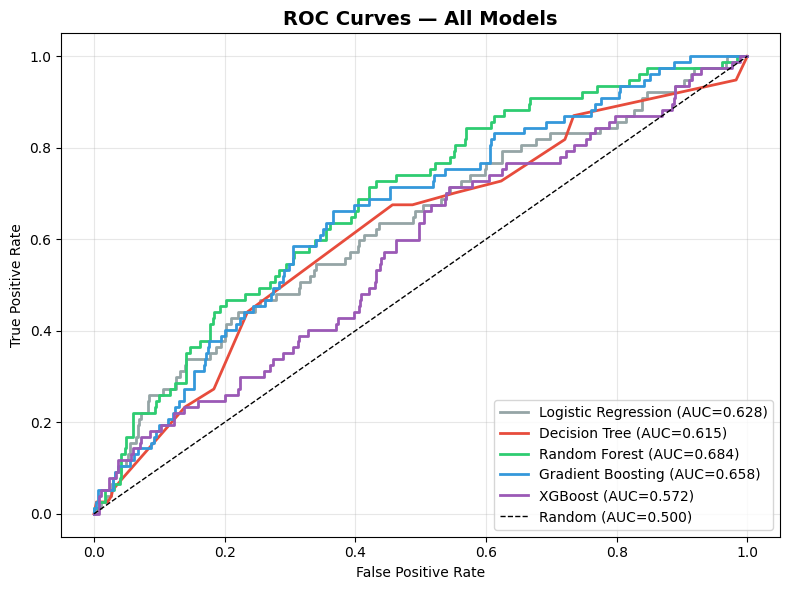

Top 5 Most Important Features:
  Credit_Score                  : 0.0849
  Employment_Years              : 0.0809
  Credit_x_Income               : 0.0669
  Debt_to_Income                : 0.0662
  Loan_to_Income                : 0.0639


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#95a5a6', '#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

for (name, (_, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Most Important Features:")
for _, row in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:30s}: {row['Importance']:.4f}")


In [19]:
print("\nHyperparameter Tuning with GridSearchCV...")

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0,
                  subsample=0.8, colsample_bytree=0.8),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print(f"\nTuned XGBoost on Test Set:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_best):.4f}")


Hyperparameter Tuning with GridSearchCV...

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV AUC-ROC: 0.6172

Tuned XGBoost on Test Set:
  Accuracy:  0.8717
  AUC-ROC:   0.6689


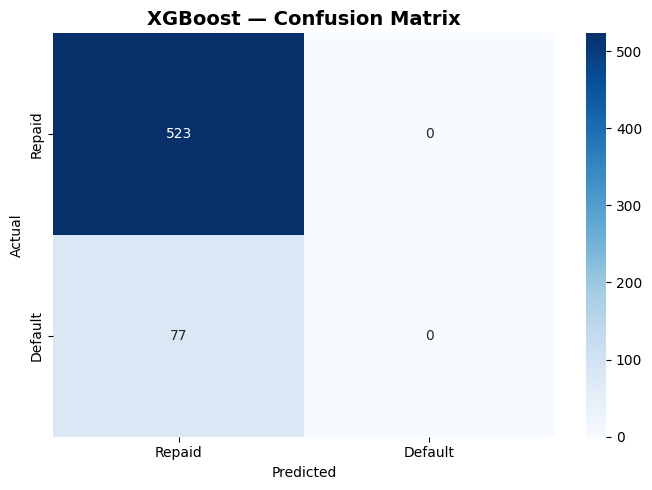

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Default'],
            yticklabels=['Repaid', 'Default'], ax=ax)
ax.set_title('XGBoost — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
tn, fp, fn, tp = cm.ravel()
avg_loan = df['Loan_Amount'].mean()

print(f"\nBUSINESS IMPACT ANALYSIS:")
print(f"  True Positives (caught defaults):  {tp}")
print(f"  False Negatives (missed defaults):  {fn}")
print(f"  False Positives (rejected good loans): {fp}")
print(f"  True Negatives (approved good loans):  {tn}")
print(f"\n  Average loan: ${avg_loan:,.0f}")
print(f"  Caught {tp} defaults → saved ~${tp * avg_loan * 0.3:,.0f} in losses")
print(f"  Missed {fn} defaults → lost ~${fn * avg_loan * 0.3:,.0f}")
print(f"  Rejected {fp} good loans → lost ~${fp * avg_loan * 0.05:,.0f} in interest")


BUSINESS IMPACT ANALYSIS:
  True Positives (caught defaults):  0
  False Negatives (missed defaults):  77
  False Positives (rejected good loans): 0
  True Negatives (approved good loans):  523

  Average loan: $125,913
  Caught 0 defaults → saved ~$0 in losses
  Missed 77 defaults → lost ~$2,908,599
  Rejected 0 good loans → lost ~$0 in interest


In [22]:
print("\n" + "=" * 70)
print("     PROJECT 10 COMPLETE — GRADIENT BOOSTING & XGBOOST")
print("=" * 70)
print(f"""
CONCEPTS COVERED:
  ✅ Decision Trees (Gini impurity, recursive splitting)
  ✅ Random Forest (bagging — parallel independent trees, majority vote)
  ✅ Gradient Boosting (boosting — sequential trees, each fixes previous errors)
  ✅ XGBoost (optimized boosting + regularization + speed)
  ✅ Bagging vs Boosting (variance reduction vs bias reduction)
  ✅ Hyperparameter tuning (GridSearchCV — exhaustive search)
  ✅ Feature importance (tree-based)
  ✅ Class imbalance handling (scale_pos_weight)
  ✅ ROC curves for model comparison
  ✅ Business impact analysis (cost of errors)
  ✅ Model evolution: LogReg → Tree → Forest → Boosting → XGBoost

CHARTS GENERATED:
  01 — EDA (default rates by credit score, DTI, employment, etc.)
  02 — ROC curves (all 5 models compared)
  03 — XGBoost feature importance
  04 — Confusion matrix with business impact

KEY INTERVIEW TAKEAWAYS:
  • Decision Tree: flowchart of yes/no splits using Gini impurity
  • Random Forest = BAGGING: many trees in parallel, vote → reduces VARIANCE
  • Gradient Boosting = BOOSTING: trees in sequence, each fixes errors → reduces BIAS
  • XGBoost = Gradient Boosting + regularization + speed + missing value handling
  • Key hyperparameters: max_depth (tree complexity), learning_rate (step size),
    n_estimators (number of trees), subsample/colsample (randomness)
  • XGBoost > RF > Tree > LogReg for most tabular classification tasks
  • LogReg is still preferred when INTERPRETABILITY matters most
  • GridSearchCV: try all parameter combinations with cross-validation
""")
print("=" * 70)


     PROJECT 10 COMPLETE — GRADIENT BOOSTING & XGBOOST

CONCEPTS COVERED:
  ✅ Decision Trees (Gini impurity, recursive splitting)
  ✅ Random Forest (bagging — parallel independent trees, majority vote)
  ✅ Gradient Boosting (boosting — sequential trees, each fixes previous errors)
  ✅ XGBoost (optimized boosting + regularization + speed)
  ✅ Bagging vs Boosting (variance reduction vs bias reduction)
  ✅ Hyperparameter tuning (GridSearchCV — exhaustive search)
  ✅ Feature importance (tree-based)
  ✅ Class imbalance handling (scale_pos_weight)
  ✅ ROC curves for model comparison
  ✅ Business impact analysis (cost of errors)
  ✅ Model evolution: LogReg → Tree → Forest → Boosting → XGBoost

CHARTS GENERATED:
  01 — EDA (default rates by credit score, DTI, employment, etc.)
  02 — ROC curves (all 5 models compared)
  03 — XGBoost feature importance
  04 — Confusion matrix with business impact

KEY INTERVIEW TAKEAWAYS:
  • Decision Tree: flowchart of yes/no splits using Gini impurity
  • Ra